/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-LR/ssp585/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6sulfur/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/NCAR/CESM2-WACCM/ssp585/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/NCAR/CESM2-WACCM/G6sulfur/r1i1p1f2/Amon/pr/gn/latest


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


/badc/cmip6/data/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp585/r1i1p1f1/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/Amon/pr/gr/latest


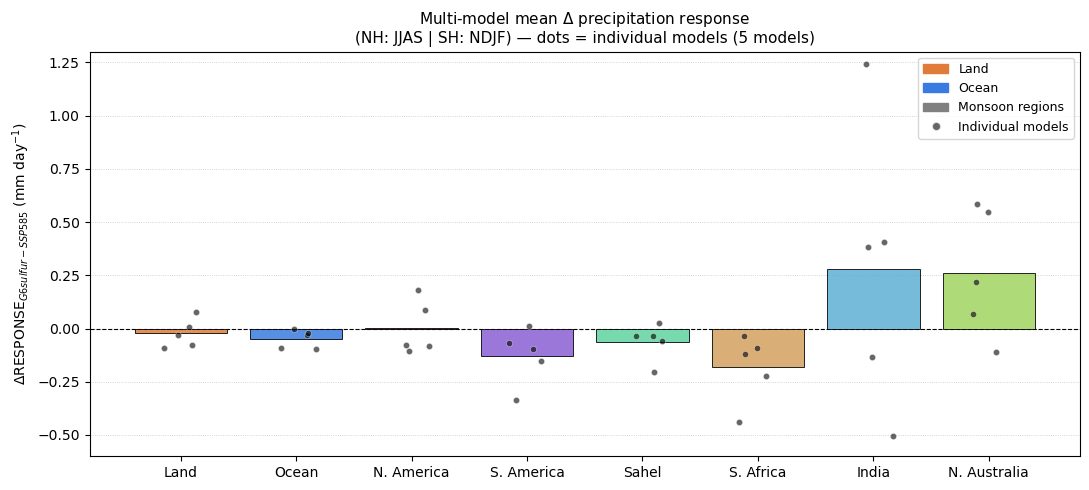

In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as 

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")

# =========================
# User-defined metadata
# =========================

varname = "pr"
varname_T = "tas"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


#Experiment details
EXPERIMENTS = {
    # "piControl":     {"project": "CMIP",        "scenario": "piControl",  "color": "black"},
    # "HIST":          {"project": "CMIP",        "scenario": "historical", "color": "black"},
    # "SSP245":        {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":        {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":       {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":      {"project": "GeoMIP",      "scenario": "G6sulfur"},
}



def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means




all_results = {}

for model_name, model_meta in MODELS.items():

    var = {}
    var_by_year = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():
        # if exp not in ["SSP245", "G6sulfur", "G6solar", "piControl"]:
        #     continue

        # open dataset
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]


        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )

        ######## ds for PR ############
        print(str(base))
        # ds = mf.open_files(str(base))
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        ###############################

        
        # ds = ...
        var[exp] = mf.read_var(ds, varname)
        

    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR
    # ----------------------------
    for exp, da in var.items():
        var_by_year[exp] = {
            "SUM": mf.seasonal_mean_by_year_old(da, 6, 9),
            "WIN": mf.seasonal_mean_by_year_old(da, 11, 2),
            "ANN":  mf.seasonal_mean_by_year_old(da, 1, 12)
        }
        
    
    # ----------------------------
    # 3) 30-YR CLIMATOLOGY
    # ----------------------------
    results = {}
    
    for exp in var_by_year:
    
        results[exp] = {}
    
        for season in ["SUM", "WIN", "ANN"]:
    
            da_year = var_by_year[exp][season]
    
            clim_mean, clim_sd, block_means = climatology_and_uncertainty(da_year)
    
            results[exp][season] = {
                "mean": clim_mean,
                "sd": clim_sd,
                "blocks": block_means
            }

    # ----------------------------
    # 4) Δbias (AFTER results built)
    # ----------------------------
    if "G6sulfur" in results and "SSP585" in results:

        delta = {}
        delta_sd = {}

        
        for season in ["SUM", "WIN", "ANN"]:

            mean_ssp = results["G6sulfur"][season]["mean"] 
            mean_hist = results["SSP585"][season]["mean"]
    
            sd_ssp = results["G6sulfur"][season]["sd"]
            sd_hist = results["SSP585"][season]["sd"]
    
            delta[season] = ( mean_ssp - mean_hist )
    
            delta_sd[season] = np.sqrt(sd_ssp**2 + sd_hist**2)
    
        results["delta_bias"] = delta
        results["delta_bias_sd"] = delta_sd
        
    # Save results for models:
    all_results[model_name] = results


def compute_results(all_results, lat_slice=None, lon_slice=None):
    """
    Optionally subset and compute all dask arrays in all_results dict (all models).
    
    Parameters:
    -----------
    all_results : dict of {model_name: results_dict} with dask arrays
    lat_slice : tuple e.g. (-30, 30) or None for global
    lon_slice : tuple e.g. (60, 100) or None
    
    Returns:
    --------
    all_results_computed : dict of {model_name: computed results}
    """
    import dask

    def subset(da):
        if lat_slice is not None:
            da = da.sel(lat=slice(*lat_slice))
        if lon_slice is not None:
            da = da.sel(lon=slice(*lon_slice))
        return da

    lazy_all = {}
    for model_name, results in all_results.items():
        lazy_all[model_name] = {
            'G6sulfur': {
                'SUM': {'mean': subset(results['G6sulfur']['SUM']['mean']),
                        'sd':   subset(results['G6sulfur']['SUM']['sd'])},
                'WIN': {'mean': subset(results['G6sulfur']['WIN']['mean']),
                        'sd':   subset(results['G6sulfur']['WIN']['sd'])}
            },
            'SSP585': {
                'SUM': {'mean': subset(results['SSP585']['SUM']['mean']),
                        'sd':   subset(results['SSP585']['SUM']['sd'])},
                'WIN': {'mean': subset(results['SSP585']['WIN']['mean']),
                        'sd':   subset(results['SSP585']['WIN']['sd'])}
            },
            'delta_bias':    {'SUM': subset(results['delta_bias']['SUM']),
                              'WIN': subset(results['delta_bias']['WIN'])},
            'delta_bias_sd': {'SUM': subset(results['delta_bias_sd']['SUM']),
                              'WIN': subset(results['delta_bias_sd']['WIN'])}
        }

    return dask.compute(lazy_all)[0]


# Slice for tropics
trop_lat=30
all_results_tropics  = compute_results(all_results, lat_slice=(-trop_lat, trop_lat))


import xesmf as xe
import xarray as xr
import numpy as np

def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 

    

def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def plot_regional_bar(all_results_tropics, trop_bound=None, agree_threshold=4,
                      land_mask=None):
    """
    Bar plot of multi-model mean delta_bias (stitched: NH=JJAS, SH=NDJF)
    broken down by Land, Ocean, and the Bombardi & Boos monsoon regions.
    Error bars show inter-model standard deviation.
    
    Parameters
    ----------
    all_results_tropics : dict
        Same dict passed to plot_multimodel_delta_bias.
    trop_bound : int, optional
        Tropical boundary in degrees lat. Default 30.
    land_mask : xarray.DataArray, optional
        Boolean DataArray (True=land) on the same grid as the regridded data.
        If None, the function tries to build one from cartopy's Natural Earth
        dataset via regionmask (must be installed).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import xarray as xr
    import warnings

    if trop_bound is None:
        trop_bound = 30

    # ------------------------------------------------------------------ #
    # 1.  Build per-model stitched delta_bias fields
    # ------------------------------------------------------------------ #
    delta_list = []
    for model_name, results in all_results_tropics.items():
        if 'delta_bias' not in results:
            continue
        da_SUM = roll_lon(regrid_to_common(results['delta_bias']['SUM'], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(results['delta_bias']['WIN'], target_lat=trop_bound))
        lat    = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError("No models with 'delta_bias' found in all_results_tropics.")

    stacked = xr.concat(delta_list, dim='model')   # (model, lat, lon)
    lat = stacked.lat.values
    lon = stacked.lon.values

    # ------------------------------------------------------------------ #
    # 2.  Land / ocean mask
    # ------------------------------------------------------------------ #
    if land_mask is None:
        try:
            import regionmask
            land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            mask_np  = land_110.mask(lon, lat)          # NaN = ocean, 0 = land
            land_mask_da = xr.DataArray(~np.isnan(mask_np.values),
                                        dims=['lat', 'lon'],
                                        coords={'lat': lat, 'lon': lon})
        except ImportError:
            warnings.warn("regionmask not found – using a rough sin-latitude proxy. "
                          "Install regionmask for a proper land mask.")
            land_mask_da = xr.DataArray(np.zeros((len(lat), len(lon)), dtype=bool),
                                        dims=['lat', 'lon'],
                                        coords={'lat': lat, 'lon': lon})
    else:
        land_mask_da = land_mask.interp(lat=lat, lon=lon, method='nearest') > 0.5

    ocean_mask_da = ~land_mask_da

    # ------------------------------------------------------------------ #
    # 3.  Monsoon region boxes (Bombardi & Boos 2021)
    # ------------------------------------------------------------------ #
    regions = {
        'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
        'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
        'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
        'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
        'India':        {'lon': (73,  87),   'lat': (15,    27)},
        'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
    }

    # ------------------------------------------------------------------ #
    # 4.  Area-weighted spatial mean per model per region
    # ------------------------------------------------------------------ #
    weights = np.cos(np.deg2rad(lat))   # (lat,)
    weights_da = xr.DataArray(weights, dims=['lat'], coords={'lat': lat})

    def area_mean(data_3d, mask_2d):
        """data_3d: (model,lat,lon), mask_2d: (lat,lon) bool."""
        masked = data_3d.where(mask_2d)
        w      = weights_da.where(mask_2d)
        return (masked * w).sum(['lat', 'lon']) / w.sum(['lat', 'lon'])

    def to_180(lon):
        """Convert 0-360 longitude to -180-180."""
        return ((lon + 180) % 360) - 180

    def box_mask(lon_range, lat_range):
        lon0, lon1 = to_180(lon_range[0]), to_180(lon_range[1])
        lat0, lat1 = lat_range
        lon_da = stacked.lon
        lat_da = stacked.lat
        # Handle cases where the box crosses the antimeridian after conversion
        if lon0 <= lon1:
            lon_sel = (lon_da >= lon0) & (lon_da <= lon1)
        else:
            # Box wraps around -180/180 boundary
            lon_sel = (lon_da >= lon0) | (lon_da <= lon1)
        return lon_sel & (lat_da >= lat0) & (lat_da <= lat1)

    labels   = []
    means    = []
    stds     = []
    colors   = []

    # Land & Ocean
    for label, mask, color in [('Land',  land_mask_da,  '#E07B3A'),
                                 ('Ocean', ocean_mask_da, '#3A7BE0')]:
        per_model = area_mean(stacked, mask).values        # (n_models,)
        labels.append(label)
        means.append(float(np.nanmean(per_model)))
        stds.append(float(np.nanstd(per_model, ddof=1)))
        colors.append(color)

    # Monsoon regions — distinct palette
    region_colors = ['#D45F8B', '#8B5FD4', '#5FD4A0', '#D4A05F', '#5FAFD4', '#A0D45F']
    for (rname, coords), rcol in zip(regions.items(), region_colors):
        bmask   = box_mask(coords['lon'], coords['lat'])
        per_model = area_mean(stacked, bmask).values
        labels.append(rname)
        means.append(float(np.nanmean(per_model)))
        stds.append(float(np.nanstd(per_model, ddof=1)))
        colors.append(rcol)

    means = np.array(means)
    stds  = np.array(stds)
    x     = np.arange(len(labels))

    # ------------------------------------------------------------------ #
    # 5.  Collect per-model values alongside means
    # ------------------------------------------------------------------ #
    per_model_all = []

    # Land & Ocean — recompute to store per-model arrays
    per_model_all = []
    labels   = []
    means    = []
    colors   = []

    for label, mask, color in [('Land',  land_mask_da,  '#E07B3A'),
                                 ('Ocean', ocean_mask_da, '#3A7BE0')]:
        pm = area_mean(stacked, mask).values
        labels.append(label)
        means.append(float(np.nanmean(pm)))
        colors.append(color)
        per_model_all.append(pm)

    region_colors = ['#D45F8B', '#8B5FD4', '#5FD4A0', '#D4A05F', '#5FAFD4', '#A0D45F']
    for (rname, coords), rcol in zip(regions.items(), region_colors):
        bmask = box_mask(coords['lon'], coords['lat'])
        pm    = area_mean(stacked, bmask).values
        labels.append(rname)
        means.append(float(np.nanmean(pm)))
        colors.append(rcol)
        per_model_all.append(pm)

    means = np.array(means)
    x     = np.arange(len(labels))

    # ------------------------------------------------------------------ #
    # 6.  Plot bars + individual model markers
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(figsize=(11, 5))

    bars = ax.bar(x, means,
                  color=colors, edgecolor='k', linewidth=0.7,
                  alpha=0.85, zorder=3)

    # Jitter model markers so they don't overlap
    rng = np.random.default_rng(42)
    n_models = len(delta_list)
    for i, pm in enumerate(per_model_all):
        jitter = rng.uniform(-0.18, 0.18, size=len(pm))
        ax.scatter(x[i] + jitter, pm,
                   color='k', s=20, zorder=5,
                   alpha=0.6, linewidths=0.4,
                   edgecolors='white')

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('$\\Delta$RESPONSE$_{G6sulfur - SSP585}$ (mm day$^{-1}$)', fontsize=10)
    ax.set_title(
        f'Multi-model mean $\\Delta$ precipitation response\n'
        f'(NH: JJAS | SH: NDJF) — dots = individual models '
        f'({n_models} models)',
        fontsize=11
    )
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=1)

    legend_patches = [
        mpatches.Patch(color='#E07B3A', label='Land'),
        mpatches.Patch(color='#3A7BE0', label='Ocean'),
        mpatches.Patch(color='grey',    label='Monsoon regions'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                   markersize=6, alpha=0.6, label='Individual models'),
    ]
    ax.legend(handles=legend_patches, fontsize=9, loc='upper right')
    ax.set_ylim(-0.6,1.30)

    plt.tight_layout()
    plt.show()
    return fig, {'labels': labels, 'means': means, 'colors': colors, 'per_model_all': per_model_all}

fig, bar_data_G6sulfur_SSP585 = plot_regional_bar(all_results_tropics, trop_bound=30)
# %store bar_data_G6sulfur_SSP585
# fig.savefig("Rainfall_change_G6sulfur-SSP585_2.png", dpi=150, bbox_inches="tight")
